<center><h1>Gong_Jiale_HW2</h1></center>
<br>
<br>

Name: Gongjiale
<br>
Github Username: jialegong
<br>
USC ID: 1387502580

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from io import BytesIO
from zipfile import ZipFile
import requests

Get the Cycle Power Plant Data Set

In [8]:
url = (
    "https://archive.ics.uci.edu/static/public/294/"
    "combined%2Bcycle%2Bpower%2Bplant.zip"
)

response = requests.get(url)
response.raise_for_status()

with ZipFile(BytesIO(response.content)) as zip_file:
    excel_data = zip_file.read("CCPP/Folds5x2_pp.xlsx")

xls = pd.ExcelFile(BytesIO(excel_data))
print("Sheet names:", xls.sheet_names)

df = pd.read_excel(xls, sheet_name="Sheet1")

print(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Sheet names: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4', 'Sheet5']
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
Shape: (9568, 5)
Columns: ['AT', 'V', 'AP', 'RH', 'PE']


### (b) Exploring the data

#### i. rows and columns

In [11]:
print("Number of rows and columns:", df.shape)
df.info()

Number of rows and columns: (9568, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


#### ii. pairwise scatterplots of all the varianbles

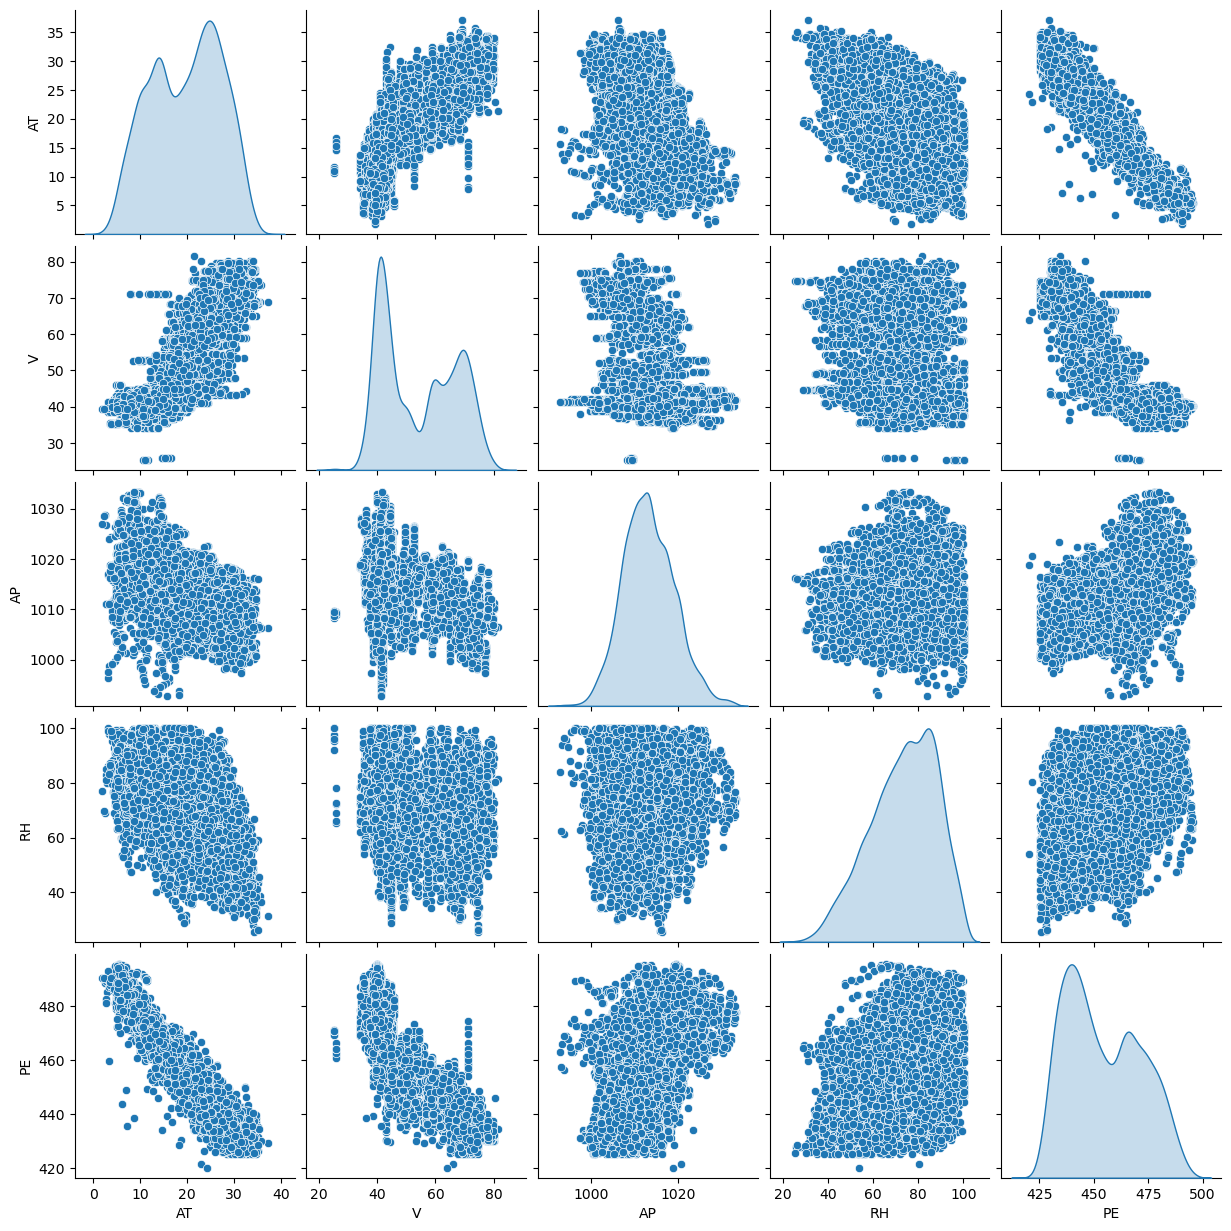

       AT      V     AP     RH     PE
AT  1.000  0.844 -0.508 -0.543 -0.948
V   0.844  1.000 -0.414 -0.312 -0.870
AP -0.508 -0.414  1.000  0.100  0.518
RH -0.543 -0.312  0.100  1.000  0.390
PE -0.948 -0.870  0.518  0.390  1.000


In [13]:
sns.pairplot(df, diag_kind='kde')
plt.show()
print(df.corr(numeric_only=True).round(3))

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [15]:
summary = df.describe().T
summary['range'] = summary['max'] - summary['min']
summary['IQR'] = summary['75%'] - summary['25%']
summary = summary[['mean', '50%', 'min', 'max', 'range', '25%', '75%', 'IQR']]
summary = summary.rename(columns={'50%': 'median'})
print(summary.round(3))

        mean    median     min      max  range       25%      75%     IQR
AT    19.651    20.345    1.81    37.11  35.30    13.510    25.72  12.210
V     54.306    52.080   25.36    81.56  56.20    41.740    66.54  24.800
AP  1013.259  1012.940  992.89  1033.30  40.41  1009.100  1017.26   8.160
RH    73.309    74.975   25.56   100.16  74.60    63.328    84.83  21.502
PE   454.365   451.550  420.26   495.76  75.50   439.750   468.43  28.680


The dataset contains 9,568 rows and 5 columns. Each row represents one hourly averaged observation of the power plant. AT, V, AP, and RH are the four predictors, while PE is the response variable representing net hourly electrical energy output. The pairwise scatterplots show that AT (Ambient Temperature) and V (Exhaust Vacuum) have the strongest apparent relationships with the response variable PE. Both show a clear negative association with PE: as AT or V increases, PE generally decreases. The relationship between PE and AT appears approximately linear but with some possible curvature, while the relationship between PE and V also shows a clear negative trend.
In contrast, AP and RH show weaker but still noticeable positive marginal associations with PE, with correlations of 0.518 and 0.390, respectively. Their scatterplots are more diffuse than those of AT and V.
The predictor variables are also correlated with one another. In particular, AT and V show a positive association, while AT and RH and V and RH show negative associations. These correlations among predictors suggest that the estimated coefficients in a multiple regression model may differ from those obtained from separate simple linear regressions.
The distributions of several variables are not symmetric. AT, V, RH, and PE show some evidence of multiple modes or concentrations in particular ranges. There are also some observations that appear relatively isolated from the main patterns. These observations should be investigated as potential outliers, but they should not automatically be removed without evidence that they are erroneous.
Overall, the scatterplots suggest that AT and V are likely to be important predictors of PE, while AP and RH have weaker individual relationships with PE. The possible curvature in some relationships also motivates investigating nonlinear terms in later parts of the analysis.

### (c) Simple Linear Regression

Simple Linear Regression: PE ~ AT
Intercept: 497.0341
Coefficient: -2.1713
p-value: 0.0000e+00
R-squared: 0.8989
1.5×IQR outliers in AT: 0
Studentized residual |t|>3 outliers: 42


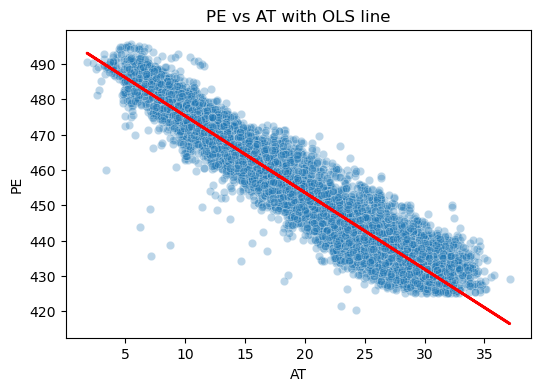

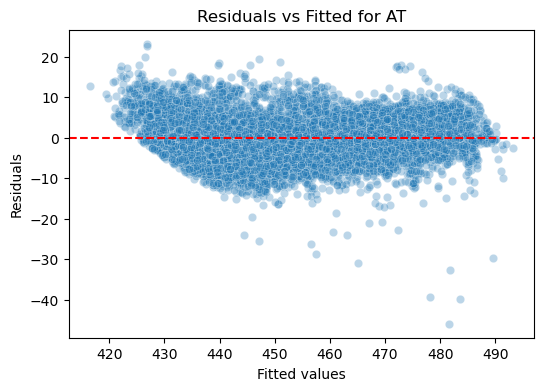

Simple Linear Regression: PE ~ V
Intercept: 517.8015
Coefficient: -1.1681
p-value: 0.0000e+00
R-squared: 0.7565
1.5×IQR outliers in V: 0
Studentized residual |t|>3 outliers: 33


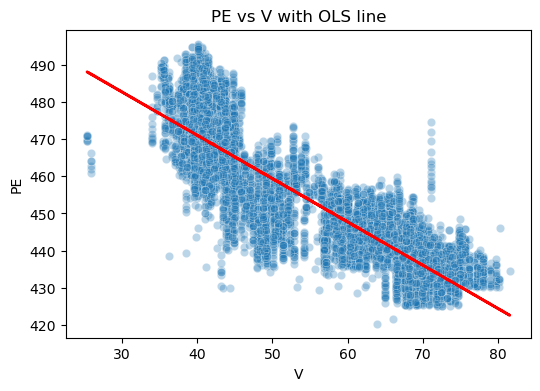

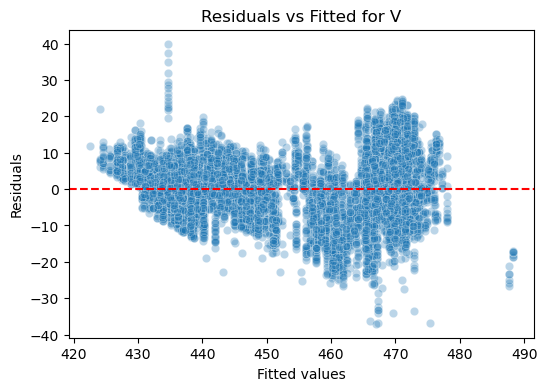

Simple Linear Regression: PE ~ AP
Intercept: -1055.2610
Coefficient: 1.4899
p-value: 0.0000e+00
R-squared: 0.2688
1.5×IQR outliers in AP: 88
Studentized residual |t|>3 outliers: 29


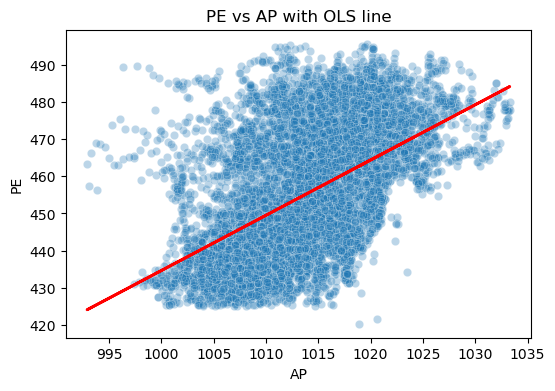

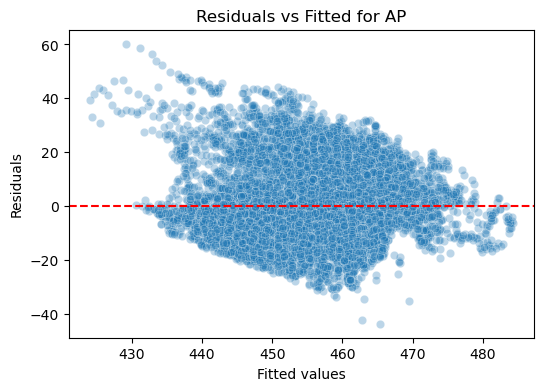

Simple Linear Regression: PE ~ RH
Intercept: 420.9618
Coefficient: 0.4557
p-value: 0.0000e+00
R-squared: 0.1519
1.5×IQR outliers in RH: 12
Studentized residual |t|>3 outliers: 2


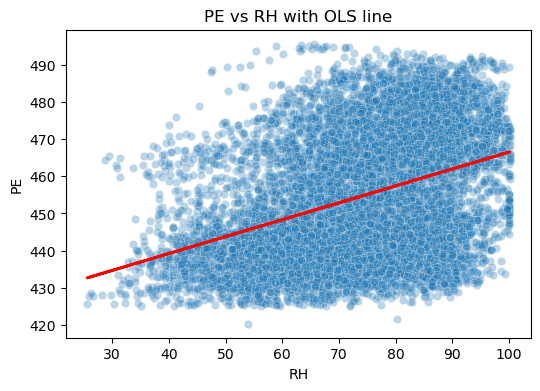

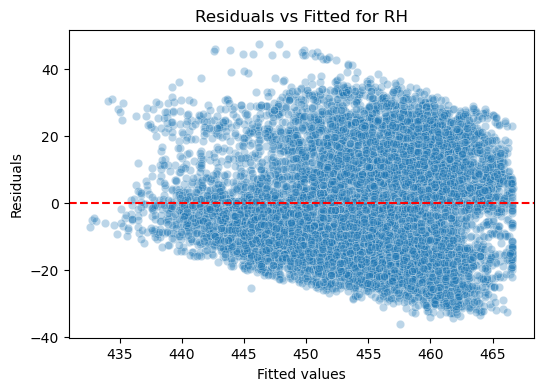


Summary of Simple Linear Regressions:
  Predictor  Intercept  Coefficient  p-value  R-squared  IQR Outliers  \
0        AT   497.0341      -2.1713      0.0     0.8989             0   
1         V   517.8015      -1.1681      0.0     0.7565             0   
2        AP -1055.2610       1.4899      0.0     0.2688            88   
3        RH   420.9618       0.4557      0.0     0.1519            12   

   Std Residual Outliers  
0                     42  
1                     33  
2                     29  
3                      2  


In [18]:
predictors = ['AT', 'V', 'AP', 'RH']
response = 'PE'

results = []

for p in predictors:
    print("=" * 70)
    print(f"Simple Linear Regression: {response} ~ {p}")
    
    X = sm.add_constant(df[[p]])
    y = df[response]
    model = sm.OLS(y, X).fit()
    
    intercept = model.params['const']
    coef = model.params[p]
    p_value = model.pvalues[p]
    r_squared = model.rsquared
    
    Q1 = df[p].quantile(0.25)
    Q3 = df[p].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    iqr_outliers = df[(df[p] < lower_fence) | (df[p] > upper_fence)]
    n_iqr_outliers = len(iqr_outliers)
    
    influence = model.get_influence()
    std_resid = influence.resid_studentized_internal
    n_std_outliers = np.sum(np.abs(std_resid) > 3)
    
    print(f"Intercept: {intercept:.4f}")
    print(f"Coefficient: {coef:.4f}")
    print(f"p-value: {p_value:.4e}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"1.5×IQR outliers in {p}: {n_iqr_outliers}")
    print(f"Studentized residual |t|>3 outliers: {n_std_outliers}")
    
    results.append({
        'Predictor': p,
        'Intercept': intercept,
        'Coefficient': coef,
        'p-value': p_value,
        'R-squared': r_squared,
        'IQR Outliers': n_iqr_outliers,
        'Std Residual Outliers': n_std_outliers
    })
    
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[p], y=df[response], alpha=0.3)
    plt.plot(df[p], model.predict(X), color='red', linewidth=2)
    plt.xlabel(p)
    plt.ylabel(response)
    plt.title(f'{response} vs {p} with OLS line')
    plt.show()
    
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=model.fittedvalues, y=model.resid, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    plt.title(f'Residuals vs Fitted for {p}')
    plt.show()

results_df = pd.DataFrame(results)
print("\nSummary of Simple Linear Regressions:")
print(results_df.round(4))


AT and V have strong negative linear associations with PE, while AP and RH have weaker positive linear associations. All four predictors are statistically significant in their respective simple linear regression models (p < 0.001). The 1.5×IQR rule identifies no potential outliers for AT or V, 88 for AP, and 12 for RH. Using |studentized residual| > 3, there are 42, 33, 29, and 2 potential regression outliers for AT, V, AP, and RH, respectively. These observations should be investigated rather than automatically removed.

### (d) Multiple Regression

In [21]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']
X = sm.add_constant(X)

model_multi = sm.OLS(y, X).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:33:54   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

### (e) 1c Compare to 1d

    Simple (1c)  Multiple (1d)
AT    -2.171320      -1.977513
V     -1.168135      -0.233916
AP     1.489872       0.062083
RH     0.455650      -0.158054


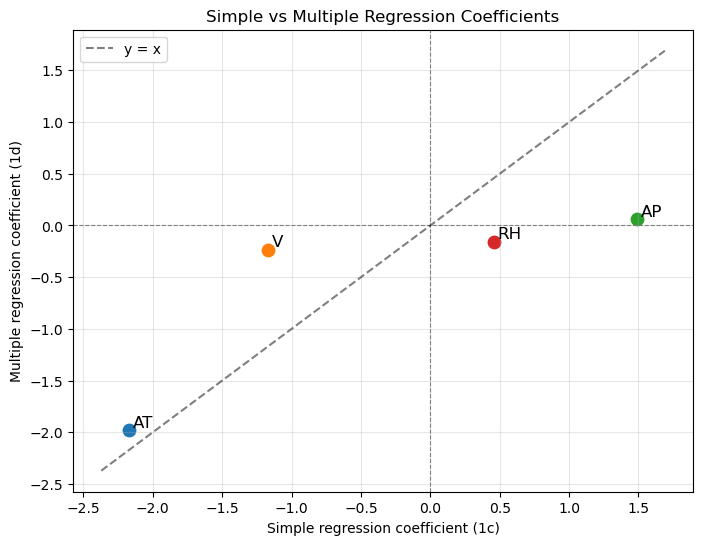

In [23]:
predictors = ['AT', 'V', 'AP', 'RH']
y = df['PE']

# c: simple regression coefficients 
simple_coefs = {}
for p in predictors:
    X = sm.add_constant(df[[p]])
    model = sm.OLS(y, X).fit()
    simple_coefs[p] = model.params[p]

# d: multiple regression coefficients
X_all = sm.add_constant(df[predictors])
multi_model = sm.OLS(y, X_all).fit()
multi_coefs = {p: multi_model.params[p] for p in predictors}

comp_df = pd.DataFrame({
    'Simple (1c)': simple_coefs,
    'Multiple (1d)': multi_coefs
})
print(comp_df)

plt.figure(figsize=(8, 6))

for p in predictors:
    plt.scatter(simple_coefs[p], multi_coefs[p], s=80)
    plt.text(simple_coefs[p] + 0.03,
             multi_coefs[p] + 0.03,
             p,
             fontsize=12)

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# Optional: y = x reference line
all_vals = list(simple_coefs.values()) + list(multi_coefs.values())
lims = [min(all_vals) - 0.2, max(all_vals) + 0.2]
plt.plot(lims, lims, 'k--', alpha=0.5, label='y = x')

plt.xlabel('Simple regression coefficient (1c)')
plt.ylabel('Multiple regression coefficient (1d)')
plt.title('Simple vs Multiple Regression Coefficients')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The comparison shows that the simple regression coefficients are not the same as the multiple regression coefficients. This is expected because the predictors are correlated with each other.

In particular:

· AT changes from (-2.1713) in the simple regression to (-1.9775) in the multiple regression. · V and AP change substantially in magnitude when all predictors are included. · RH changes sign, from (+0.4556) in the simple regression to (-0.1580) in the multiple regression. · The simple regressions describe marginal associations, while the multiple regression coefficients represent the association of each predictor with PE while controlling for the other predictors. · The large condition number in the multiple regression is consistent with multicollinearity, which can contribute to changes in the estimated coefficients.

Therefore, although all four predictors are statistically significant in the multiple regression model, their estimated effects differ substantially from the simple regression results.



### (f) Nonlinear Association

In [26]:
predictors = ['AT', 'V', 'AP', 'RH']
y = df['PE']

results = []

for p in predictors:
    z = (df[p] - df[p].mean()) / df[p].std()
    
    X_poly_df = pd.DataFrame({
        'const': 1,
        'z': z,
        'z2': z ** 2,
        'z3': z ** 3
    })

    model = sm.OLS(y, X_poly_df).fit()

    print("=" * 70)
    print(f"Cubic polynomial regression (Standardized): PE ~ {p} + {p}^2 + {p}^3")
    print(f"Condition Number: {model.condition_number:.2f}") # 标准化后条件数会大幅下降
    print(model.summary())

    pval_x1 = model.pvalues['z']
    pval_x2 = model.pvalues['z2']
    pval_x3 = model.pvalues['z3']

    print(f"p-value for {p}:   {pval_x1:.4e}")
    print(f"p-value for {p}^2: {pval_x2:.4e}")
    print(f"p-value for {p}^3: {pval_x3:.4e}")
    print(f"R-squared (cubic): {model.rsquared:.4f}")

    joint_test = model.f_test("z2 = 0, z3 = 0")
    print(f"Joint F-test (z2=0, z3=0): F={joint_test.fvalue:.2f}, p-value={joint_test.pvalue:.4e}")

    results.append({
        'Predictor': p,
        'p-value X': pval_x1,
        'p-value X^2': pval_x2,
        'p-value X^3': pval_x3,
        'Joint F p-value': joint_test.pvalue,
        'R2 cubic': model.rsquared
    })

results_df = pd.DataFrame(results)
print("\nSummary of cubic polynomial regressions:")
print(results_df.round(6))

Cubic polynomial regression (Standardized): PE ~ AT + AT^2 + AT^3
Condition Number: 5.50
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:33:54   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

Yes, there is evidence of nonlinear association between the predictors and the response.

AT shows the strongest and most practically meaningful nonlinear association.

V shows statistically significant nonlinear terms, providing evidence of nonlinearity.

AP shows significant nonlinear terms, with a moderate improvement in R^2.

RH shows statistically significant nonlinear terms, although the improvement in R^2 is very small.

Because the sample size is very large n=9568, even small nonlinear effects can produce very small p-values. Overall, the results provide statistical evidence of nonlinear associations between the predictors and PE.

### (g) Interactions of Predictors

In [29]:
formula = ('PE ~ AT + V + AP + RH '
           '+ AT:V + AT:AP + AT:RH '
           '+ V:AP + V:RH + AP:RH')

model_interaction = smf.ols(formula, data=df).fit()
print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:33:54   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

Yes, there is evidence of association of interactions of predictors with the response.

Several pairwise interaction terms—especially AT × V, AT × RH, V × AP, and AP × RH are statistically significant at the 5% significance level. This means that the effect of one predictor on PE is not constant across the values of another predictor. The full interaction model improves the fit compared with the additive model from part 1(d): (R^2) increases from about 0.929 to 0.936.

Note: The condition number is very large (1.70 x 10^8), indicating strong multicollinearity among the main effects and interaction terms. Therefore, individual coefficients should be interpreted with caution, even though several interaction terms are statistically significant.

### (h) Improvement

In [32]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model 1: additive linear model
X_train1 = sm.add_constant(X_train)
X_test1 = sm.add_constant(X_test)

model1 = sm.OLS(y_train, X_train1).fit()

train_pred1 = model1.predict(X_train1)
test_pred1 = model1.predict(X_test1)

mse1_train = mean_squared_error(y_train, train_pred1)
mse1_test = mean_squared_error(y_test, test_pred1)

# Model 2: full quadratic model + interactions
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

feature_names = poly.get_feature_names_out(X.columns)

X_train_poly = pd.DataFrame(X_train_poly, columns=feature_names, index=X_train.index)
X_test_poly = pd.DataFrame(X_test_poly, columns=feature_names, index=X_test.index)

X_train_poly = sm.add_constant(X_train_poly)
X_test_poly = sm.add_constant(X_test_poly)

model2_full = sm.OLS(y_train, X_train_poly).fit()

def backward_elimination(X, y, threshold=0.05):
    X = X.copy()
    main_effects = {'AT', 'V', 'AP', 'RH'}

    while True:
        model = sm.OLS(y, X).fit()
        pvals = model.pvalues.drop('const', errors='ignore')

        candidates = pvals.drop(
            labels=list(main_effects),
            errors='ignore'
        )

        if candidates.empty or candidates.max() <= threshold:
            break

        X = X.drop(columns=[candidates.idxmax()])

    return model, X

model2_sel, X_train_sel = backward_elimination(X_train_poly, y_train)
X_test_sel = X_test_poly[X_train_sel.columns]

train_pred2 = model2_sel.predict(X_train_sel)
test_pred2 = model2_sel.predict(X_test_sel)

mse2_train = mean_squared_error(y_train, train_pred2)
mse2_test = mean_squared_error(y_test, test_pred2)

print("Model 1: Additive linear")
print(f"Train MSE: {mse1_train:.4f}")
print(f"Test MSE:  {mse1_test:.4f}")

print("Model 2: Quadratic + interactions, after backward elimination")
print(f"Train MSE: {mse2_train:.4f}")
print(f"Test MSE:  {mse2_test:.4f}")

print("Selected terms in Model 2:")
print(X_train_sel.columns.tolist())

Model 1: Additive linear
Train MSE: 20.5808
Test MSE:  21.2399
Model 2: Quadratic + interactions, after backward elimination
Train MSE: 17.8908
Test MSE:  18.6600
Selected terms in Model 2:
['const', 'AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT AP', 'AT RH', 'AP^2', 'AP RH', 'RH^2']


Yes, we can improve the model using interaction terms and quadratic nonlinearities.

The selected model with interaction terms and quadratic nonlinearities achieves lower training and testing MSEs than the additive multiple linear regression model. The training MSE decreases from 20.5808 to 17.8908, while the testing MSE decreases from 21.2399 to 18.6600. This corresponds to an approximately 12.15% reduction in testing MSE. The additional terms capture important nonlinear and interactive effects in the data and improve the model's predictive performance.

### (i) KNN

Raw features:
Best k = 5
Train MSE = 10.6008
Test MSE  = 15.7268

Normalized features:
Best k = 4
Train MSE = 8.5914
Test MSE  = 14.3057


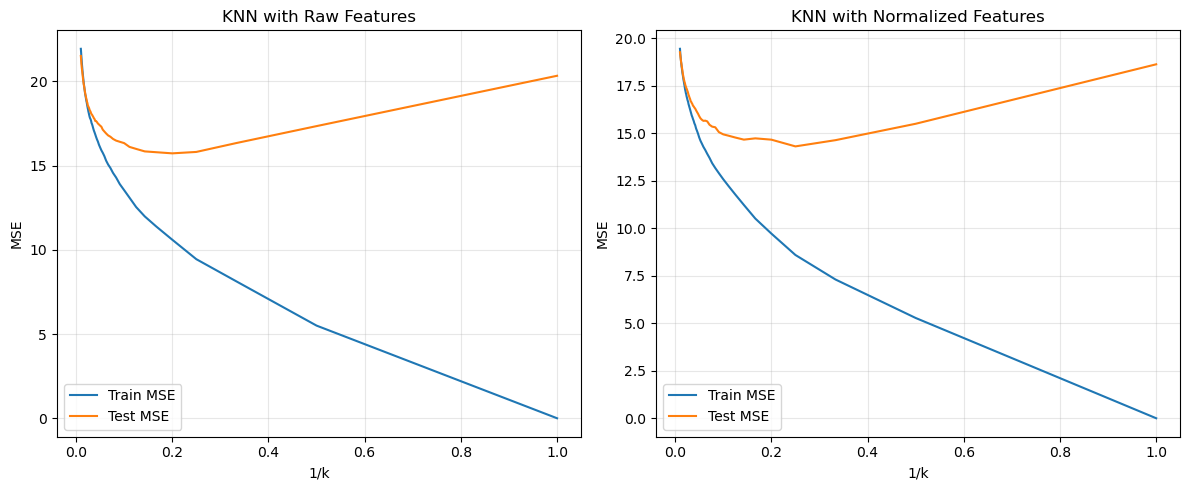

In [35]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

k_values = range(1, 101)

train_mse_raw = []
test_mse_raw = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    train_mse_raw.append(mean_squared_error(y_train, train_pred))
    test_mse_raw.append(mean_squared_error(y_test, test_pred))

best_k_raw = k_values[np.argmin(test_mse_raw)]
best_test_mse_raw = min(test_mse_raw)
best_train_mse_raw = train_mse_raw[best_k_raw - 1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_mse_norm = []
test_mse_norm = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    train_mse_norm.append(mean_squared_error(y_train, train_pred))
    test_mse_norm.append(mean_squared_error(y_test, test_pred))

best_k_norm = k_values[np.argmin(test_mse_norm)]
best_test_mse_norm = min(test_mse_norm)
best_train_mse_norm = train_mse_norm[best_k_norm - 1]

print("Raw features:")
print(f"Best k = {best_k_raw}")
print(f"Train MSE = {best_train_mse_raw:.4f}")
print(f"Test MSE  = {best_test_mse_raw:.4f}")

print("\nNormalized features:")
print(f"Best k = {best_k_norm}")
print(f"Train MSE = {best_train_mse_norm:.4f}")
print(f"Test MSE  = {best_test_mse_norm:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(1/np.array(list(k_values)), train_mse_raw, label='Train MSE')
plt.plot(1/np.array(list(k_values)), test_mse_raw, label='Test MSE')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN with Raw Features')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(1/np.array(list(k_values)), train_mse_norm, label='Train MSE')
plt.plot(1/np.array(list(k_values)), test_mse_norm, label='Test MSE')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN with Normalized Features')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### (j ) Compare KNN and Linear

The normalized KNN model with k=4 achieves the lowest testing MSE of 14.3057, compared with 15.7268 for raw KNN and 18.6600 for the best linear regression model from part (h). Thus, KNN with normalized features provides better predictive performance on the test set. However, the linear regression model remains more interpretable because its coefficients describe the relationships between the predictors and the response. Overall, KNN with normalized features captures the predictive patterns in this dataset more effectively, while the linear model provides clearer interpretation of the underlying relationships.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

n extremely large, p small. Flexible. With many observations and few predictors, there is enough data to estimate a complex model without overfitting. A flexible method can capture nonlinearities or interactions if they exist.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

p extremely large, n small, Inflexible, With many predictors and few observations, flexible methods suffer from the curse of dimensionality and overfit. An inflexible method has lower variance and is more reliable. 

### (c) The relationship between the predictors and response is highly non-linear.

Relationship is highly non-linear. Flexible. An inflexible method (linear regression) will underfit because it cannot represent the true nonlinear relationship. A flexible method can approximate the nonlinearity better.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Error variance (sigma^2 = Var) is extremely high. Inflexible. When the noise is very large, a flexible method is likely to fit the noise rather than the signal, leading to overfitting and poor test performance. An inflexible method is more stable and has lower variance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

Euclidean distances to the test point
d=sqrt(x1^2+x2^2+x3^2)
The Euclidean distance from observation i to the test point (0,0,0) is:
| Observation | X1 | X2 | X3 | Distance | Y |
|---:|---:|---:|---:|---:|:---|
| 1 | 0 | 3 | 0 | 3.000 | Red |
| 2 | 2 | 0 | 0 | 2.000 | Red |
| 3 | 0 | 1 | 3 | 3.162 | Red |
| 4 | 0 | 1 | 2 | 2.236 | Green |
| 5 | -1 | 0 | 1 | 1.414 | Green |
| 6 | 1 | 1 | 1 | 1.732 | Red |

sorted by distance obs.5<obs.6<obs.2<obs4<obs.1<obs.3

### (b) What is our prediction with K = 1? Why?

Prediction with K = 1

With K=1, we use the single nearest neighbor. Nearest neighbor: Obs. 5, distance 1.414, response Y =Green. Prediction: Green. Reason: The 1-nearest neighbor directly assigns the class of the closest observation.

### (c) What is our prediction with K = 3? Why?

 Prediction with K = 3 With K=3, we use the three nearest neighbors:

Obs. 5: Green
Obs. 6: Red
Obs. 2: Red
Among these three neighbors: Green: 1 Red: 2

Majority vote: Red (2 out of 3). Prediction: Red. Reason: The 3-nearest neighbors are majority Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

Best K for a highly non-linear Bayes decision boundary If the Bayes decision boundary is highly non-linear, we would expect the best value of K to be small.

Reason: A small K makes the model more flexible, allowing it to approximate complex, non-linear decision boundaries. A large K produces a smoother, more rigid decision boundary, which may underfit and fail to capture the non-linear structure. However, K too small can lead to high variance and overfitting. The optimal K is usually chosen by cross-validation to balance bias and variance.

Conclusion: For a highly non-linear Bayes decision boundary, a small K is generally preferred.